# Task 2: Nonlinear Baseline (XGBoost)

This notebook implements the nonlinear baseline asked for in Task 2(ii) of the assignment.
The model is an XGBoost gradient-boosted tree regressor with per-output hyperparameter tuning:
one independent `RandomizedSearchCV` is run for each of the 15 modeled outputs, so every
output gets its own tuned model.

The 4 deterministic outputs (`T3`, `P3`, `P4`, `MeOH_purity_stream4`) are exact identities with inputs
or other outputs, so they are recovered by direct assignment and no model is trained for them.

The evaluation protocol (5-fold CV stratified on `n4_total == 0`, plus held-out test metrics)
matches the Elastic Net baseline in `EDA&ElasticNet.ipynb` so the comparison is fair.

## 0: Install dependencies

In [1]:
# Run this cell once; restart the kernel if xgboost is freshly installed.
import subprocess, sys
for pkg in ["xgboost"]:
    try:
        __import__(pkg)
        print(f"{pkg} already installed")
    except ImportError:
        print(f"Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        print("\n*** Restart the kernel before running the remaining cells. ***")

xgboost already installed


## 1: Imports

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

random_state = 42

## 2: Load data

In [ ]:
TRAIN_PATH = Path("dataset/train.csv")
TEST_PATH  = Path("dataset/test.csv")

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

# Column order in the CSV: first 9 are inputs, remaining 19 are outputs.
input_cols  = list(train.columns[:9])
output_cols = list(train.columns[9:])

X_train = train[input_cols]
y_train = train[output_cols]
X_test  = test[input_cols]
y_test  = test[output_cols]

# No-liquid indicator: rows where the flash produces zero liquid (all liquid outputs == 0).
# Used only for CV stratification and diagnostic reporting, NOT as a model input.
no_liquid_train = train["n4_total"].eq(0)
no_liquid_test  = test["n4_total"].eq(0)

print(f"Train : {len(train):>5} rows | {len(input_cols)} inputs | {len(output_cols)} outputs")
print(f"Test  : {len(test):>5} rows")
print(f"No-liquid rows — train: {no_liquid_train.sum()} | test: {no_liquid_test.sum()}")
print(f"\nInput columns  : {input_cols}")
print(f"Output columns : {output_cols}")

# Deterministic outputs: exact identities with inputs or other outputs, do not train.
deterministic_from_input = {"T3": "T_flash", "P3": "P_R", "P4": "P_R"}
redundant_from_output    = {"MeOH_purity_stream4": "x_MeOH_4"}
# Trace-fraction targets trained in log-space with target StandardScaler to improve R²
log_transform_outputs    = {"x_H2_4"}
log_target_scalers       = {}   # fitted StandardScaler per log-space output; populated below

model_output_cols = [
    c for c in output_cols
    if c not in deterministic_from_input and c not in redundant_from_output
]

print(f"\nOutputs modeled by XGBoost ({len(model_output_cols)}): {model_output_cols}")
print(f"Deterministic (recovered from inputs) : {list(deterministic_from_input.keys())}")
print(f"Redundant     (recovered from outputs): {list(redundant_from_output.keys())}")
print(f"Log-space targets                     : {sorted(log_transform_outputs)}")

## 3: Helper function

In [4]:
def regression_metrics_by_output(y_true, y_pred, columns):
    """Return a DataFrame with RMSE, MAE, R² for each output column."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    rows = []
    for j, col in enumerate(columns):
        t = y_true[:, j]
        p = y_pred[:, j]
        r2 = r2_score(t, p) if len(t) >= 2 else np.nan
        rows.append({
            "output": col,
            "RMSE":   np.sqrt(mean_squared_error(t, p)),
            "MAE":    mean_absolute_error(t, p),
            "R2":     r2,
        })
    return pd.DataFrame(rows)

## 4: Stratified cross-validation splits

5-fold CV stratified on the no-liquid indicator, same as the Elastic Net setup.

In [5]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
cv_splits = list(kf.split(X_train, no_liquid_train))

print("CV splits (train / val / no-liquid-in-val per fold):")
for i, (tr_idx, val_idx) in enumerate(cv_splits, 1):
    nl = int(no_liquid_train.iloc[val_idx].sum())
    print(f"  Fold {i}: train={len(tr_idx)}, val={len(val_idx)}, no_liquid_in_val={nl}")

CV splits (train / val / no-liquid-in-val per fold):
  Fold 1: train=6400, val=1600, no_liquid_in_val=2
  Fold 2: train=6400, val=1600, no_liquid_in_val=2
  Fold 3: train=6400, val=1600, no_liquid_in_val=3
  Fold 4: train=6400, val=1600, no_liquid_in_val=3
  Fold 5: train=6400, val=1600, no_liquid_in_val=3


## 5: Per-output hyperparameter search

60 random draws from the parameter grid, evaluated independently for each of the 15 modeled outputs.
The 4 deterministic outputs (`T3`, `P3`, `P4`, `MeOH_purity_stream4`) are excluded, since they are
recovered by direct assignment after prediction and would trivially report R²=1 and RMSE near 0.

n_jobs strategy:
- `XGBRegressor(n_jobs=1)`: single-threaded per model, avoids nested parallelism.
- `RandomizedSearchCV(n_jobs=-1)`: all CPU cores parallelize the 60 x 5 fold evaluations.
- Progress printed manually (one line per output).

This cell runs 15 x 60 x 5 = 4,500 XGBoost fits (parallelized across folds), about 5 to 10 minutes.

In [6]:
param_dist = {
    "model__n_estimators":     [200, 500, 1000, 2000],
    "model__max_depth":        [3, 4, 5, 6],
    "model__learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "model__subsample":        [0.6, 0.75, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.75, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma":            [0, 0.1, 0.5],
    "model__reg_alpha":        [0, 0.01, 0.1, 1.0],   # L1 leaf-weight regularization
    "model__reg_lambda":       [0.5, 1, 2, 5],         # L2 leaf-weight regularization
}

best_params_per_output = {}
for j, col in enumerate(model_output_cols):
    if col in log_transform_outputs:
        print(f"[{j+1:2d}/{len(model_output_cols)}] {col:25s}  skipped — log-space search handled separately")
        continue
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  XGBRegressor(tree_method="hist", random_state=random_state, n_jobs=1)),
    ])
    search_j = RandomizedSearchCV(
        pipe, param_dist,
        n_iter=60,
        cv=cv_splits,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        random_state=random_state + j,
        verbose=0,
    )
    search_j.fit(X_train, y_train[col])
    best_params_per_output[col] = {
        k.replace("model__", ""): v
        for k, v in search_j.best_params_.items()
    }
    print(f"[{j+1:2d}/{len(model_output_cols)}] {col:25s}  best CV MSE = {-search_j.best_score_:.6f}")

[ 1/15] Q1_MW                      best CV MSE = 0.000283


[ 2/15] Q2_MW                      best CV MSE = 0.000002


[ 3/15] T_reactor_out              best CV MSE = 0.063115


[ 4/15] X_CO                       best CV MSE = 0.000002


[ 5/15] n3_total                   best CV MSE = 19.488484


...

[10/15] n4_total                   best CV MSE = 1.134361


[11/15] x_CO_4                     best CV MSE = 0.000000
[12/15] x_H2_4                     skipped — log-space search handled separately


[13/15] x_MeOH_4                   best CV MSE = 0.000796


[14/15] x_H2O_4                    best CV MSE = 0.000056


[15/15] MeOH_recovery              best CV MSE = 0.000062


### x_H2_4: log-space target correction

In the first search x_H2_4 was treated like any other output, but its test R² is only 0.77 while
its RMSE is about 3e-5. The problem is not prediction quality, it is the scale of the target.

Why not recover it from the sum-to-one constraint?
Stream 4 satisfies x_CO_4 + x_H2_4 + x_MeOH_4 + x_H2O_4 = 1, so x_H2_4 could be recovered
by difference: 1 - x_CO_4 - x_MeOH_4 - x_H2O_4. But that pushes all three partners'
prediction errors onto x_H2_4. x_MeOH_4 alone has RMSE about 0.030, which is about 1000 times larger
than x_H2_4's current RMSE of about 3e-5. The recovered x_H2_4 would then have RMSE about 0.031,
much worse than direct prediction.

Why log-transform plus StandardScaler on the log target?
H2 is a non-condensable gas with near-zero solubility in liquid methanol and water. x_H2_4 is a trace
fraction (about 1e-4 to 1e-3) with a near log-normal distribution: small absolute changes
correspond to large relative changes. In linear space the target variance is tiny, so even a
good model scores R² about 0.77. In log-space the target spans several orders of magnitude, which
gives the tree regressor real signal to learn.

Also, raw log(x_H2_4) sits in about [-9.2, -6.9], well outside the unit-scale range for which
the `reg_alpha` and `reg_lambda` candidates in `param_dist` were calibrated. A StandardScaler applied
to the log target brings it to about [-2, +2], matching the regularisation grid. This mirrors the
`TransformedTargetRegressor(StandardScaler)` approach used in the Elastic Net baseline.

The model is trained on `StandardScaler(log(x_H2_4))` and predictions are inverse-transformed then
exponentiated back to original units. x_H2_4 is excluded from the main search above and has its own
search cell below. No-liquid rows (x_H2_4 = 0) are handled by clipping to 1e-10 before
the log, so exp(inverse_transform(prediction)) is about 0 for those rows.

In [ ]:
# Hyperparameter search for x_H2_4 in log-space with StandardScaler on the log target.
# x_H2_4 is a trace fraction (about 1e-4 to 1e-3) skipped in the main search above.
# Raw log(x_H2_4) sits in about [-9.2, -6.9]; StandardScaling brings it to about [-2, +2] so
# reg_alpha/reg_lambda in param_dist are properly calibrated for unit-scale targets.
col   = "x_H2_4"
j     = model_output_cols.index(col)
log_y = np.log(np.clip(y_train[col].values, 1e-10, None))

target_sc    = StandardScaler()
log_y_scaled = target_sc.fit_transform(log_y.reshape(-1, 1)).ravel()
log_target_scalers[col] = target_sc   # stored for CV loop, final fitting, and test prediction

pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  XGBRegressor(tree_method="hist", random_state=random_state, n_jobs=1)),
])
search_log = RandomizedSearchCV(
    pipe_log, param_dist,
    n_iter=60, cv=cv_splits,
    scoring="neg_mean_squared_error", n_jobs=-1,
    random_state=random_state + j, verbose=0,
)
search_log.fit(X_train, log_y_scaled)
best_params_per_output[col] = {
    k.replace("model__", ""): v
    for k, v in search_log.best_params_.items()
}
print(f"x_H2_4 (log-space, target-scaled) best CV MSE(scaled-log) = {-search_log.best_score_:.8f}")
print(f"Best params: {best_params_per_output[col]}")

## 6: Best XGBoost parameters

In [8]:
print("Best XGBoost params per modeled output:")
for col, params in best_params_per_output.items():
    print(f"  {col}: {params}")

Best XGBoost params per modeled output:
  Q1_MW: {'subsample': 0.75, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 2000, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.75}
  Q2_MW: {'subsample': 0.75, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.9}
  T_reactor_out: {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 1.0, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.75}
  X_CO: {'subsample': 0.6, 'reg_lambda': 0.5, 'reg_alpha': 0.01, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.75}
  n3_total: {'subsample': 0.75, 'reg_lambda': 0.5, 'reg_alpha': 0.01, 'n_estimators': 2000, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}
  y_CO_3: {'subsample': 

## 7: CV fold loop with best hyperparameters

Re-run the 5 folds using the best hyperparameters to assemble out-of-fold predictions
for every training row in physical units, then compute per-fold and per-output metrics.

In [9]:
def make_output_model(col):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model",  XGBRegressor(
            **best_params_per_output[col],
            tree_method="hist",
            random_state=random_state,
            n_jobs=1,
        )),
    ])

def recover_deterministic(pred_df, X_ref):
    """Fill in the 4 deterministic outputs from inputs / other predictions."""
    for out_col, in_col in deterministic_from_input.items():
        pred_df[out_col] = X_ref[in_col].values
    for out_col, src_col in redundant_from_output.items():
        pred_df[out_col] = pred_df[src_col].values
    return pred_df[output_cols]   # restore original column order

cv_predictions   = pd.DataFrame(index=y_train.index, columns=output_cols, dtype=float)
fold_metric_rows = []

for fold_id, (fit_idx, val_idx) in enumerate(cv_splits, start=1):
    fold_preds = {}
    for col in model_output_cols:
        m = make_output_model(col)
        if col in log_transform_outputs:
            log_y_fit = np.log(np.clip(y_train[col].iloc[fit_idx].values, 1e-10, None))
            log_y_fit_scaled = log_target_scalers[col].transform(log_y_fit.reshape(-1, 1)).ravel()
            m.fit(X_train.iloc[fit_idx], log_y_fit_scaled)
            raw_pred = m.predict(X_train.iloc[val_idx])
            log_pred = log_target_scalers[col].inverse_transform(raw_pred.reshape(-1, 1)).ravel()
            fold_preds[col] = np.exp(log_pred)
        else:
            m.fit(X_train.iloc[fit_idx], y_train[col].iloc[fit_idx])
            fold_preds[col] = m.predict(X_train.iloc[val_idx])

    fold_pred_df  = pd.DataFrame(fold_preds, index=X_train.index[val_idx])
    fold_pred_df  = recover_deterministic(fold_pred_df, X_train.iloc[val_idx])
    fold_pred_arr = fold_pred_df.values

    cv_predictions.iloc[val_idx, :] = fold_pred_arr

    fold_metrics = regression_metrics_by_output(
        y_train.iloc[val_idx], fold_pred_arr, output_cols
    )
    fold_metric_rows.append({
        "fold":           fold_id,
        "rows":           len(val_idx),
        "no_liquid_rows": int(no_liquid_train.iloc[val_idx].sum()),
        "mean_RMSE":      fold_metrics["RMSE"].mean(),
        "mean_MAE":       fold_metrics["MAE"].mean(),
        "mean_R2":        fold_metrics["R2"].mean(skipna=True),
    })
    print(f"  Fold {fold_id}: RMSE={fold_metrics['RMSE'].mean():.4f}  "
          f"MAE={fold_metrics['MAE'].mean():.4f}  R²={fold_metrics['R2'].mean(skipna=True):.4f}")

xgb_fold_metrics = pd.DataFrame(fold_metric_rows)
xgb_fold_metrics.round(5)

  Fold 1: RMSE=0.3029  MAE=0.2361  R²=0.9868


  Fold 2: RMSE=0.3035  MAE=0.2389  R²=0.9883


  Fold 3: RMSE=0.2938  MAE=0.2295  R²=0.9862


  Fold 4: RMSE=0.3173  MAE=0.2447  R²=0.9857


  Fold 5: RMSE=0.3146  MAE=0.2438  R²=0.9856


,fold,rows,no_liquid_rows,mean_RMSE,mean_MAE,mean_R2
0,1,1600,2,0.30294,0.23612,0.98682
1,2,1600,2,0.30354,0.23885,0.98835
2,3,1600,3,0.29377,0.22954,0.98616
3,4,1600,3,0.31727,0.24470,0.98568
4,5,1600,3,0.31457,0.24377,0.98558


## 8: CV metric summary (mean ± std across folds)

In [10]:
xgb_cv_summary = (
    xgb_fold_metrics[["mean_RMSE", "mean_MAE", "mean_R2"]]
    .agg(["mean", "std"])
    .T
)
print("XGBoost CV summary (mean ± std across 5 folds):")
xgb_cv_summary.round(5)

XGBoost CV summary (mean ± std across 5 folds):


,mean,std
mean_RMSE,0.30642,0.00955
mean_MAE,0.23860,0.00617
mean_R2,0.98652,0.00114


## 9: CV per-output metrics

In [ ]:
xgb_cv_per_output = regression_metrics_by_output(
    y_train, cv_predictions, output_cols
).sort_values("RMSE", ascending=False)

print("CV per-output metrics (sorted by RMSE):")
xgb_cv_per_output.round(5)

CV per-output metrics (sorted by RMSE, worst first):


,output,RMSE,MAE,R2
6,n3_total,4.41458,3.46109,0.99964
12,n4_total,1.06506,0.83352,0.99776
2,T_reactor_out,0.25123,0.19639,0.99908
15,x_MeOH_4,0.02822,0.00759,0.96708
18,MeOH_purity_stream4,0.02822,0.00759,0.96708
0,Q1_MW,0.01681,0.01327,0.99885
17,MeOH_recovery,0.00785,0.00477,0.99808
16,x_H2O_4,0.00748,0.00418,0.99764
8,y_H2_3,0.00175,0.00135,0.99925
7,y_CO_3,0.00162,0.00128,0.99935


## 10: CV regime diagnostics

Separate metrics for all rows, normal (liquid) rows, and the degenerate no-liquid rows.

In [12]:
diagnostic_rows = []
masks = {
    "all_rows":       pd.Series(True, index=y_train.index),
    "liquid_rows":    ~no_liquid_train,
    "no_liquid_rows":  no_liquid_train,
}
for group_name, mask in masks.items():
    grp_metrics = regression_metrics_by_output(
        y_train.loc[mask], cv_predictions.loc[mask], output_cols
    )
    diagnostic_rows.append({
        "group":     group_name,
        "rows":      int(mask.sum()),
        "mean_RMSE": grp_metrics["RMSE"].mean(),
        "mean_MAE":  grp_metrics["MAE"].mean(),
        "mean_R2":   grp_metrics["R2"].mean(skipna=True),
    })

xgb_cv_diagnostics = pd.DataFrame(diagnostic_rows)
xgb_cv_diagnostics.round(5)

,group,rows,mean_RMSE,mean_MAE,mean_R2
0,all_rows,8000,0.30663,0.23860,0.98652
1,liquid_rows,7987,0.30453,0.23816,0.98939
2,no_liquid_rows,13,0.60161,0.50804,0.54560


## 11: Fit final models on full training set

In [13]:
final_models = {}
for col in model_output_cols:
    m = make_output_model(col)
    if col in log_transform_outputs:
        log_y_fit = np.log(np.clip(y_train[col].values, 1e-10, None))
        log_y_fit_scaled = log_target_scalers[col].transform(log_y_fit.reshape(-1, 1)).ravel()
        m.fit(X_train, log_y_fit_scaled)
    else:
        m.fit(X_train, y_train[col])
    final_models[col] = m
    print(f"  Fitted model for {col}")
print(f"All {len(model_output_cols)} final models fitted on the full training set.")

  Fitted model for Q1_MW


  Fitted model for Q2_MW


  Fitted model for T_reactor_out


  Fitted model for X_CO


  Fitted model for n3_total


...

  Fitted model for n4_total
  Fitted model for x_CO_4


  Fitted model for x_H2_4


  Fitted model for x_MeOH_4


  Fitted model for x_H2O_4


  Fitted model for MeOH_recovery
All 15 final models fitted on the full training set.


## 12: Test set evaluation

`test.csv` is evaluated only once, after all hyperparameter decisions are locked.

In [14]:
test_pred_df = pd.DataFrame(index=test.index)
for col in model_output_cols:
    raw = final_models[col].predict(X_test)
    if col in log_transform_outputs:
        log_pred = log_target_scalers[col].inverse_transform(raw.reshape(-1, 1)).ravel()
        test_pred_df[col] = np.exp(log_pred)
    else:
        test_pred_df[col] = raw

# Recover deterministic outputs
for out_col, in_col in deterministic_from_input.items():
    test_pred_df[out_col] = X_test[in_col].values
for out_col, src_col in redundant_from_output.items():
    test_pred_df[out_col] = test_pred_df[src_col].values

xgb_test_predictions = test_pred_df[output_cols]   # restore original column order

xgb_test_per_output = regression_metrics_by_output(
    y_test, xgb_test_predictions, output_cols
).sort_values("RMSE", ascending=False)

print("Test per-output metrics (sorted by RMSE, worst first):")
xgb_test_per_output.round(5)

Test per-output metrics (sorted by RMSE, worst first):


,output,RMSE,MAE,R2
6,n3_total,4.16023,3.26948,0.99967
12,n4_total,0.99269,0.77495,0.99807
2,T_reactor_out,0.23069,0.17734,0.99926
15,x_MeOH_4,0.03012,0.00760,0.96198
18,MeOH_purity_stream4,0.03012,0.00760,0.96198
0,Q1_MW,0.01548,0.01230,0.99897
16,x_H2O_4,0.00907,0.00419,0.99646
17,MeOH_recovery,0.00787,0.00467,0.99809
7,y_CO_3,0.00153,0.00121,0.99942
8,y_H2_3,0.00149,0.00116,0.99945


## 13: Test aggregate summary

In [15]:
m = regression_metrics_by_output(y_test, xgb_test_predictions, output_cols)
print(
    f"XGBoost test — "
    f"RMSE: {m['RMSE'].mean():.5f} | "
    f"MAE: {m['MAE'].mean():.5f} | "
    f"R²: {m['R2'].mean(skipna=True):.5f}"
)

XGBoost test — RMSE: 0.28855 | MAE: 0.22435 | R²: 0.98657


## 14: Test regime diagnostics

In [16]:
test_diagnostic_rows = []
test_masks = {
    "all_rows":       pd.Series(True, index=y_test.index),
    "liquid_rows":    ~no_liquid_test,
    "no_liquid_rows":  no_liquid_test,
}
for group_name, mask in test_masks.items():
    if mask.sum() == 0:
        continue
    grp_metrics = regression_metrics_by_output(
        y_test.loc[mask], xgb_test_predictions.loc[mask], output_cols
    )
    test_diagnostic_rows.append({
        "group":     group_name,
        "rows":      int(mask.sum()),
        "mean_RMSE": grp_metrics["RMSE"].mean(),
        "mean_MAE":  grp_metrics["MAE"].mean(),
        "mean_R2":   grp_metrics["R2"].mean(skipna=True),
    })

xgb_test_diagnostics = pd.DataFrame(test_diagnostic_rows)
xgb_test_diagnostics.round(5)

,group,rows,mean_RMSE,mean_MAE,mean_R2
0,all_rows,2000,0.28855,0.22435,0.98657
1,liquid_rows,1996,0.28685,0.22425,0.99046
2,no_liquid_rows,4,0.31882,0.27570,0.38826


## 15: Comparison: Elastic Net vs XGBoost

Aggregate test metrics side-by-side.  
Elastic Net figures are from `EDA&ElasticNet.ipynb` (Task 2, subtask i).

In [17]:
# Elastic Net test metrics recorded in AGENT_NOTES from the completed EDA&ElasticNet.ipynb run.
elastic_net_test = {"RMSE": 0.657, "MAE": 0.486, "R2": 0.938}

xgb_test_agg = {
    "RMSE": m["RMSE"].mean(),
    "MAE":  m["MAE"].mean(),
    "R2":   m["R2"].mean(skipna=True),
}

comparison = pd.DataFrame({
    "Elastic Net (test)": elastic_net_test,
    "XGBoost (test)":     xgb_test_agg,
}).T

comparison["RMSE_delta"] = comparison["RMSE"] - elastic_net_test["RMSE"]
comparison["R2_delta"]   = comparison["R2"]   - elastic_net_test["R2"]

print("Aggregate test comparison:")
comparison.round(5)

Aggregate test comparison:


,RMSE,MAE,R2,RMSE_delta,R2_delta
Elastic Net (test),0.65700,0.48600,0.93800,0.00000,0.00000
XGBoost (test),0.28855,0.22435,0.98657,-0.36845,0.04857


In [18]:
# Per-output R² for the three outputs weakest under Elastic Net.
weak_outputs = ["y_H2O_3", "Q2_MW", "MeOH_recovery"]
elastic_net_weak_r2 = {"y_H2O_3": 0.752, "Q2_MW": 0.836, "MeOH_recovery": 0.858}

xgb_weak_r2 = (
    xgb_test_per_output
    .set_index("output")["R2"]
    .loc[weak_outputs]
    .to_dict()
)

weak_comparison = pd.DataFrame({
    "Elastic Net R²": elastic_net_weak_r2,
    "XGBoost R²":     xgb_weak_r2,
}).T

print("Per-output R² comparison on the three weakest Elastic Net outputs:")
weak_comparison.round(4)

Per-output R² comparison on the three weakest Elastic Net outputs:


,y_H2O_3,Q2_MW,MeOH_recovery
Elastic Net R²,0.7520,0.8360,0.8580
XGBoost R²,0.9935,0.9894,0.9981


## 16: Parity plots

Predicted vs actual for all 19 outputs.

- Blue: train set (CV out-of-fold predictions)
- Orange: test set
- Dots: normal (liquid) rows
- x marker: no-liquid rows (`n4_total == 0`)
- Dashed line: perfect prediction (y = x)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

TRAIN_COLOR = "#4878d0"   # blue
TEST_COLOR  = "#ee854a"   # orange

n_cols = 4
n_rows = (len(output_cols) + n_cols - 1) // n_cols   # 5 rows for 19 outputs

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5.5, n_rows * 5))
axes_flat = axes.flatten()

# Pre-compute boolean masks as numpy arrays
liq_tr  = (~no_liquid_train).values
nliq_tr = no_liquid_train.values
liq_te  = (~no_liquid_test).values
nliq_te = no_liquid_test.values

# Quick R² lookup from the already-computed test metrics table
r2_lookup = xgb_test_per_output.set_index("output")["R2"].to_dict()

for j, col in enumerate(output_cols):
    ax = axes_flat[j]

    y_tr_true = y_train[col].values
    y_tr_pred = cv_predictions[col].values.astype(float)
    y_te_true = y_test[col].values
    y_te_pred = xgb_test_predictions[col].values

    # Train, liquid rows (blue dots, semi-transparent for overplotting)
    ax.scatter(y_tr_true[liq_tr], y_tr_pred[liq_tr],
               c=TRAIN_COLOR, s=5, alpha=0.25, rasterized=True)
    # Train, no-liquid rows (blue x, prominent)
    if nliq_tr.any():
        ax.scatter(y_tr_true[nliq_tr], y_tr_pred[nliq_tr],
                   c=TRAIN_COLOR, s=60, marker="x", linewidths=1.5, zorder=5)
    # Test, liquid rows (orange dots)
    ax.scatter(y_te_true[liq_te], y_te_pred[liq_te],
               c=TEST_COLOR, s=8, alpha=0.5, rasterized=True)
    # Test, no-liquid rows (orange x)
    if nliq_te.any():
        ax.scatter(y_te_true[nliq_te], y_te_pred[nliq_te],
                   c=TEST_COLOR, s=60, marker="x", linewidths=1.5, zorder=5)

    # Parity (y = x) line
    all_vals = np.concatenate([y_tr_true, y_tr_pred, y_te_true, y_te_pred])
    lo, hi   = all_vals.min(), all_vals.max()
    pad      = max((hi - lo) * 0.05, 1e-6)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=0.8, zorder=3)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)

    r2_te = r2_lookup.get(col, float("nan"))
    ax.set_title(f"{col}\ntest R²={r2_te:.4f}", fontsize=8)
    ax.set_xlabel("Actual",    fontsize=7)
    ax.set_ylabel("Predicted", fontsize=7)
    ax.tick_params(labelsize=7)

# Hide the one unused subplot (20 - 19 = 1)
for j in range(len(output_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

# Shared legend with all four marker types
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=TRAIN_COLOR,
           markersize=8, label="Train – liquid"),
    Line2D([0], [0], marker="x", color=TRAIN_COLOR, markersize=9,
           markeredgewidth=1.5, label="Train – no-liquid"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=TEST_COLOR,
           markersize=8, label="Test – liquid"),
    Line2D([0], [0], marker="x", color=TEST_COLOR,  markersize=9,
           markeredgewidth=1.5, label="Test – no-liquid"),
]
fig.legend(handles=legend_elements, loc="lower right", fontsize=9,
           bbox_to_anchor=(1.0, 0.0), framealpha=0.9)

fig.suptitle(
    "XGBoost — Parity plots  (blue = train CV out-of-fold · orange = test · × = no-liquid rows)",
    fontsize=11, y=1.005
)
plt.tight_layout()
plt.show()

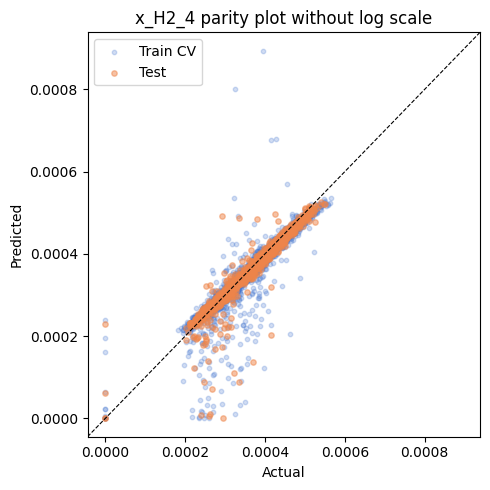

In [20]:
col = "x_H2_4"

fig, ax = plt.subplots(figsize=(5, 5))

# Train CV out-of-fold predictions
ax.scatter(
    y_train[col], cv_predictions[col],
    c=TRAIN_COLOR, s=10, alpha=0.25, label="Train CV"
)

# Test predictions
ax.scatter(
    y_test[col], xgb_test_predictions[col],
    c=TEST_COLOR, s=15, alpha=0.5, label="Test"
)

all_vals = np.concatenate([
    y_train[col].values, cv_predictions[col].values.astype(float),
    y_test[col].values, xgb_test_predictions[col].values.astype(float)
])
lo, hi = all_vals.min(), all_vals.max()
pad = max((hi - lo) * 0.05, 1e-6)

ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=0.8)
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title(f"{col} parity plot without log scale")
ax.legend()
plt.tight_layout()
plt.show()


## 17: Save fitted surrogate

In [21]:
# Save the fitted XGBoost surrogate for reuse (constraint analysis, Task 4, etc.)
import joblib
from pathlib import Path

xgb_artifact = {
    "final_models":            final_models,           # dict: output_col -> fitted Pipeline(StandardScaler, XGBRegressor)
    "log_target_scalers":      log_target_scalers,     # StandardScaler for log-space outputs (x_H2_4)
    "input_cols":              input_cols,
    "output_cols":             output_cols,
    "model_output_cols":       model_output_cols,
    "deterministic_from_input": deterministic_from_input,
    "redundant_from_output":   redundant_from_output,
    "log_transform_outputs":   log_transform_outputs,
    "best_params_per_output":  best_params_per_output,
}
save_dir = Path("models/task2")
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "xgboost.joblib"
joblib.dump(xgb_artifact, save_path)
print(f"Saved XGBoost surrogate -> {save_path}  ({save_path.stat().st_size/1e6:.1f} MB)")


Saved XGBoost surrogate -> models\task2\xgboost.joblib  (25.0 MB)


## 18: Sum-to-one constraint violation (diagnostic)

XGBoost has no closure layer, so its independently-predicted mole fractions need not sum to 1. This cell measures the mean and maximum absolute violation on the held-out test set.

In [22]:
# Sum-to-one constraint violation of the UNCONSTRAINED XGBoost predictions (test set).
# XGBoost predicts every mole fraction independently with no closure layer, so the four
# fractions in each stream are not forced to sum to 1. We quantify that violation here.
vapor_cols  = ["y_CO_3", "y_H2_3", "y_MeOH_3", "y_H2O_3"]   # Sigma should equal 1 on every row
liquid_cols = ["x_CO_4", "x_H2_4", "x_MeOH_4", "x_H2O_4"]   # Sigma = 1 on liquid rows, 0 on no-liquid rows

vapor_sum  = xgb_test_predictions[vapor_cols].sum(axis=1)
liquid_sum = xgb_test_predictions[liquid_cols].sum(axis=1)

vapor_err = (vapor_sum - 1.0).abs()
liquid_err_liquid = (liquid_sum[~no_liquid_test.values] - 1.0).abs()   # target 1 where liquid exists
liquid_err_noliq  = (liquid_sum[ no_liquid_test.values] - 0.0).abs()   # target 0 where no liquid

print("XGBoost sum-to-one constraint violation on the test set (unconstrained predictions)")
print(f"  Vapor  |Sigma y_*_3 - 1|  (all {len(vapor_err)} rows)        : mean={vapor_err.mean():.3e}  max={vapor_err.max():.3e}")
print(f"  Liquid |Sigma x_*_4 - 1|  (liquid rows: {(~no_liquid_test).sum()})       : mean={liquid_err_liquid.mean():.3e}  max={liquid_err_liquid.max():.3e}")
print(f"  Liquid |Sigma x_*_4 - 0|  (no-liquid rows: {no_liquid_test.sum()}, target 0): mean={liquid_err_noliq.mean():.3e}  max={liquid_err_noliq.max():.3e}")


XGBoost sum-to-one constraint violation on the test set (unconstrained predictions)
  Vapor  |Sigma y_*_3 - 1|  (all 2000 rows)        : mean=1.461e-03  max=7.102e-03
  Liquid |Sigma x_*_4 - 1|  (liquid rows: 1996)       : mean=6.943e-03  max=3.727e-01
  Liquid |Sigma x_*_4 - 0|  (no-liquid rows: 4, target 0): mean=7.022e-01  max=8.397e-01
